CW searches can be multi-messenger too.

We can use electromagnetic observations of 'known' sources to target for their gravitational wave emission in PTA data. 

For example, see Iguchi et. al https://iopscience.iop.org/article/10.1088/2041-8205/724/2/L166/pdf 
who provide EM constraints on parameters for the candidate SMBHB system in 3C 66B.

Let's use these constraints to do a targeted CW search for this system.

# THE MULTI-MESSENGER IPTA 2026 CW HUNT STARTS HERE!

In [1]:
import os,glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const

# enterprise
import enterprise
from enterprise.pulsar import Pulsar
from enterprise.signals import parameter, white_signals, gp_signals, signal_base, utils

# enterprise extensions
from enterprise_extensions import models, model_utils
from enterprise_extensions.frequentist import optimal_statistic as OS
from enterprise_extensions.deterministic import cw_block_circ
from enterprise_extensions.sampler import setup_sampler

# sampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

#plotting
import corner

#diagnostics
import la_forge.core as co
import la_forge.diagnostics as dg

/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


# Assemble hunters

Each pulsar is described by two files:
- **.par** — the parameter file: sky position, spin period, dispersion measure, and everything needed to predict pulse arrival times.
- **.tim** — the timing file: the actual measured pulse arrival times (TOAs).


In [2]:
DATA_DIR = './hunters/'
par_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.par')))
tim_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.tim')))

#### Make Enterprise Pulsar objects

In [3]:
psrs = []
for par, tim in zip(par_files, tim_files):
    print(f"Loading {par} and {tim}...")
    psr = Pulsar(par, tim)
    psrs.append(psr)

2026-06-17 15:49:30.610 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model
2026-06-17 15:49:30.610 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-06-17 15:49:30.635 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-06-17 15:49:30.639 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-06-17 15:49:30.639 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-06-17 15:49:30.662 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-06-17 15:49:30.671 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/Users/ashokan/.astropy/cache/download/url/d3c81b5766f4bfb84e65504c8a453085/conten

Loading ./hunters/JPSR00.par and ./hunters/JPSR00.tim...


2026-06-17 15:49:30.818 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.234 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671432e+10  1.34133391e+11  5.81464894e+10] m
2026-06-17 15:49:31.234 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.235 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.235 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.236 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.236 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.237 | INFO     | pint.sol

Loading ./hunters/JPSR01.par and ./hunters/JPSR01.tim...
Loading ./hunters/JPSR02.par and ./hunters/JPSR02.tim...


2026-06-17 15:49:31.501 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-17 15:49:31.502 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-17 15:49:31.510 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-06-17 15:49:31.510 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-06-17 15:49:31.512 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.521 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671432e+10  1.34133391e+11  5.81464894e+10] m
2026-06-17 15:49:31.521 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.522 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:31.522 | IN

...

Loading ./hunters/JPSR15.par and ./hunters/JPSR15.tim...
Loading ./hunters/JPSR16.par and ./hunters/JPSR16.tim...


2026-06-17 15:49:33.297 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model
2026-06-17 15:49:33.298 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-06-17 15:49:33.325 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-06-17 15:49:33.329 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-06-17 15:49:33.330 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-06-17 15:49:33.330 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='gbt'.
2026-06-17 15:49:33.350 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-17 15:49:33.351 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-17 15:49:33.359 | DEBUG    | pint.toa:get_TOAs:3

Loading ./hunters/JPSR17.par and ./hunters/JPSR17.tim...
Loading ./hunters/JPSR18.par and ./hunters/JPSR18.tim...


2026-06-17 15:49:33.605 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-17 15:49:33.605 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-17 15:49:33.613 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-06-17 15:49:33.613 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-06-17 15:49:33.615 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:33.624 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671432e+10  1.34133391e+11  5.81464894e+10] m
2026-06-17 15:49:33.624 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:33.625 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-17 15:49:33.626 | IN

Loading ./hunters/JPSR19.par and ./hunters/JPSR19.tim...


# Understand the data

How many pulsars do we have? 

In [4]:
len(psrs)

20

What are their names?

In [5]:
print("Pulsar names:")
for psr in psrs:
    print(psr.name)

Pulsar names:
JPSR00
JPSR01
JPSR02
JPSR03
JPSR04
JPSR05
JPSR06
JPSR07
JPSR08
JPSR09
JPSR10
JPSR11
JPSR12
JPSR13
JPSR14
JPSR15
JPSR16
JPSR17
JPSR18
JPSR19


How many TOAs do each pulsar have? 

In [6]:
for psr in psrs:
    print(len(psr.toas))

147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147


What is the time span of the data for each pulsar?

In [7]:
for psr in psrs:
    end_toa = psr.toas.max()
    start_toa = psr.toas.min()
    timespan_years = (end_toa - start_toa)/(86400*365.25)
    print("Pulsar ",psr.name, " has a timespan of ", timespan_years, " years of data.")

Pulsar  JPSR00  has a timespan of  11.991786387164314  years of data.
Pulsar  JPSR01  has a timespan of  11.99178729202828  years of data.
Pulsar  JPSR02  has a timespan of  11.99178664988047  years of data.
Pulsar  JPSR03  has a timespan of  11.99178733920599  years of data.
Pulsar  JPSR04  has a timespan of  11.991786742696176  years of data.
Pulsar  JPSR05  has a timespan of  11.991787142014326  years of data.
Pulsar  JPSR06  has a timespan of  11.991785764288629  years of data.
Pulsar  JPSR07  has a timespan of  11.99178573576619  years of data.
Pulsar  JPSR08  has a timespan of  11.991785940050242  years of data.
Pulsar  JPSR09  has a timespan of  11.991785780323271  years of data.
Pulsar  JPSR10  has a timespan of  11.991786491849151  years of data.
Pulsar  JPSR11  has a timespan of  11.991786948521243  years of data.
Pulsar  JPSR12  has a timespan of  11.991786741615718  years of data.
Pulsar  JPSR13  has a timespan of  11.991786649727405  years of data.
Pulsar  JPSR14  has a ti

# Set up PTA!

You have already learnt that Pulsars have intrinsic red noise, noise contributions from ISM, the data also has white noise from various telescope/observation effects. 

In this tutorial, we will only have white noise in the data for simplicity. And so that, this tutorial can actually be completed today.

In [8]:
# timing model
tm = gp_signals.TimingModel()

#Noise can be pre-estimated from the single-pulsar noise analysis. Here, lets try to estimate white-noise along with the gravitational wave signal.
efac = parameter.Uniform(0.1, 5.0)

# white noise
ef = white_signals.MeasurementNoise(efac=efac)


##### We will search for circular orbit CW signals. So we will use the `cw_block_circ` function from enterprise_extensions to create a signal model.

We will target the sky-location and em-predicted gravitational wave signal frequency for 3C66B in our model.

In [9]:
priors_3c66b = {
    "RA": "02h23m11.5s",
    "DEC": "+42d59m30s",
    "log10_dist": 1.9755447815530847,
    "log10_freq": -7.218963061378868,
    "log10_Mc": 8.718764005203223,
    "log10_Mc_sigma": 0.3
}

#RA and Dec of the source from prior dictionary
ra_3c66b = priors_3c66b["RA"]
dec_3c66b = priors_3c66b["DEC"]


#convert RA and Dec to radians with astropy
from astropy.coordinates import SkyCoord
from astropy import units as u
ra_3c66b_radians = SkyCoord(ra=ra_3c66b, dec=dec_3c66b).ra.radian
dec_3c66b_radians = SkyCoord(ra=ra_3c66b, dec=dec_3c66b).dec.radian

cos_theta_3c66b = np.cos(np.pi/2 - dec_3c66b_radians)
phi_3c66b = ra_3c66b_radians

print(cos_theta_3c66b, phi_3c66b)

0.6818919817652986 0.6247915111878868


In [10]:
log10_fgw_3c66b = priors_3c66b["log10_freq"]
log10_dist_3c66b = priors_3c66b["log10_dist"]

# Lets crack open cw_circ_block from enterprise_extenstions, hack it to write our own cw_delay, and use that for the cw signal model.

In [11]:
from enterprise import constants as const
@signal_base.function
def cw_delay(
    toas,
    pos,
    pdist,
    cos_gwtheta=0,
    gwphi=0,
    cos_inc=0,
    log10_mc=9,
    log10_fgw=-8,
    log10_dist=None,
    log10_h=None,
    phase0=0,
    psi=0,
    psrTerm=False,
    p_phase=None,
    evolve=False,
    phase_approx=False,
    check=False,
    tref=0,
):
    """
    Function to create GW incuced residuals from a SMBMB as
    defined in Ellis et. al 2012,2013.

    :param toas:
        Pular toas in seconds
    :param pos:
        Unit vector from the Earth to the pulsar
    :param pdist:
        Pulsar distance (mean and uncertainty) [kpc]
    :param cos_gwtheta:
        Cosine of Polar angle of GW source in celestial coords [radians]
    :param gwphi:
        Azimuthal angle of GW source in celestial coords [radians]
    :param cos_inc:
        cosine of Inclination of GW source [radians]
    :param log10_mc:
        log10 of Chirp mass of SMBMB [solar masses]
    :param log10_fgw:
        log10 of Frequency of GW (twice the orbital frequency) [Hz]
    :param log10_dist:
        log10 of Luminosity distance to SMBMB [Mpc],
        used to compute strain, if not None
    :param log10_h:
        log10 of GW strain,
        used to compute distance, if not None
    :param phase0:
        Initial GW phase of source [radians]
    :param psi:
        Polarization angle of GW source [radians]
    :param psrTerm:
        Option to include pulsar term [boolean]
    :param p_phase:
        Use pulsar phase to determine distance [radian]
    :param evolve:
        Option to include/exclude full evolution [boolean]
    :param phase_approx:
        Option to include/exclude phase evolution across observation time
        [boolean]
    :param check:
        Check if frequency evolves significantly over obs. time [boolean]
    :param tref:
        Reference time for phase and frequency [s]

    :return: Vector of induced residuals

    """

    # convert units to time
    mc = 10**log10_mc * const.Tsun
    fgw = 10**log10_fgw
    gwtheta = np.arccos(cos_gwtheta)
    inc = np.arccos(cos_inc)
    
    if log10_h is None and log10_dist is None:
        raise ValueError("one of log10_dist or log10_h must be non-None")
    elif log10_h is not None and log10_dist is not None:
        raise ValueError("only one of log10_dist or log10_h can be non-None")
    elif log10_h is None:
        dist = 10**log10_dist * const.Mpc / const.c
    else:
        dist = 2 * mc ** (5 / 3) * (np.pi * fgw) ** (2 / 3) / 10**log10_h

    if check:
        # check that frequency is not evolving significantly over obs. time
        fstart = fgw * (1 - 256 / 5 * mc ** (5 / 3) * fgw ** (8 / 3) * toas[0]) ** (
            -3 / 8
        )
        fend = fgw * (1 - 256 / 5 * mc ** (5 / 3) * fgw ** (8 / 3) * toas[-1]) ** (
            -3 / 8
        )
        df = fend - fstart

        # observation time
        Tobs = toas.max() - toas.min()
        fbin = 1 / Tobs

        if np.abs(df) > fbin:
            print("WARNING: Frequency is evolving over more than one " "frequency bin.")
            print(
                "f0 = {0}, f1 = {1}, df = {2}, fbin = {3}".format(
                    fstart, fend, df, fbin
                )
            )
            return np.ones(len(toas)) * np.nan

    # get antenna pattern funcs and cosMu
    # write function to get pos from theta,phi
    fplus, fcross, cosMu = utils.create_gw_antenna_pattern(pos, gwtheta, gwphi)

    # get pulsar time
    toas -= tref
    tp = toas

    # orbital frequency
    w0 = np.pi * fgw
    phase0 /= 2  # convert GW to orbital phase
    # omegadot = 96/5 * mc**(5/3) * w0**(11/3) # Not currently used in code

    # evolution
    if evolve:
        # calculate time dependent frequency at earth and pulsar
        omega = w0 * (1 - 256 / 5 * mc ** (5 / 3) * w0 ** (8 / 3) * toas) ** (-3 / 8)
        omega_p = w0 * (1 - 256 / 5 * mc ** (5 / 3) * w0 ** (8 / 3) * tp) ** (-3 / 8)

        if p_dist > 0:
            omega_p0 = w0 * (
                1 + 256 / 5 * mc ** (5 / 3) * w0 ** (8 / 3) * p_dist * (1 - cosMu)
            ) ** (-3 / 8)
        else:
            omega_p0 = w0

        # calculate time dependent phase
        phase = phase0 + 1 / 32 / mc ** (5 / 3) * (w0 ** (-5 / 3) - omega ** (-5 / 3))

        if p_phase is None:
            phase_p = phase0 + 1 / 32 / mc ** (5 / 3) * (
                w0 ** (-5 / 3) - omega_p ** (-5 / 3)
            )
        else:
            phase_p = (
                phase0
                + p_phase
                + 1 / 32 * mc ** (-5 / 3) * (omega_p0 ** (-5 / 3) - omega_p ** (-5 / 3))
            )

    elif phase_approx:
        # monochromatic
        omega = w0
        # if p_dist > 0:
        #     omega_p = w0 * (
        #         1 + 256 / 5 * mc ** (5 / 3) * w0 ** (8 / 3) * p_dist * (1 - cosMu)
        #     ) ** (-3 / 8)
        #else:
        omega_p = w0

        # phases
        phase = phase0 + omega * toas
        if p_phase is not None:
            phase_p = phase0 + p_phase + omega_p * toas
        else:
            phase_p = (
                phase0
                + omega_p * toas
                + 1 / 32 / mc ** (5 / 3) * (w0 ** (-5 / 3) - omega_p ** (-5 / 3))
            )

    # no evolution
    else:
        # monochromatic
        omega = np.pi * fgw
        omega_p = omega

        # phases
        phase = phase0 + omega * toas
        phase_p = phase0 + omega * tp

    # define time dependent coefficients
    At = -0.5 * np.sin(2 * phase) * (3 + np.cos(2 * inc))
    Bt = 2 * np.cos(2 * phase) * np.cos(inc)
    At_p = -0.5 * np.sin(2 * phase_p) * (3 + np.cos(2 * inc))
    Bt_p = 2 * np.cos(2 * phase_p) * np.cos(inc)

    # now define time dependent amplitudes
    alpha = mc ** (5.0 / 3.0) / (dist * omega ** (1.0 / 3.0))
    alpha_p = mc ** (5.0 / 3.0) / (dist * omega_p ** (1.0 / 3.0))

    # define rplus and rcross
    rplus = alpha * (-At * np.cos(2 * psi) + Bt * np.sin(2 * psi))
    rcross = alpha * (At * np.sin(2 * psi) + Bt * np.cos(2 * psi))
    rplus_p = alpha_p * (-At_p * np.cos(2 * psi) + Bt_p * np.sin(2 * psi))
    rcross_p = alpha_p * (At_p * np.sin(2 * psi) + Bt_p * np.cos(2 * psi))

    # residuals
    # if psrTerm:
    #     res = fplus * (rplus_p - rplus) + fcross * (rcross_p - rcross)
    #else:
    res = -fplus * rplus - fcross * rcross

    return res

In [12]:
from enterprise.signals import deterministic_signals
def CWSignal(cw_wf, ecc=False, psrTerm=False, name="cw"):

    BaseClass = deterministic_signals.Deterministic(cw_wf, name=name)

    class CWSignal(BaseClass):

        def __init__(self, psr):
            super(CWSignal, self).__init__(psr)
            self._wf[""].add_kwarg(psrTerm=psrTerm)
            if ecc:
                pgam = parameter.Uniform(0, 2 * np.pi)(
                    "_".join([psr.name, "pgam", name])
                )
                self._params["pgam"] = pgam
                self._wf[""]._params["pgam"] = pgam

    return CWSignal

# Waveform  for 3c 66b

In [13]:
from enterprise.signals import parameter
#waveform
# continuous wave signal
name='3c66b'
cosinc = parameter.Uniform(-1.0, 1.0)("{}_cosinc".format(name))
log10_Mc = parameter.Uniform(6.0, 10.0)("{}_log10_Mc".format(name))
cosinc = parameter.Uniform(-1.0, 1.0)("{}_cosinc".format(name))
phase0 = parameter.Uniform(0.0, 2 * np.pi)("{}_phase0".format(name))
cos_theta_3c66b_range = parameter.Uniform(cos_theta_3c66b-0.1, cos_theta_3c66b+0.1)("{}_cos_gwtheta".format(name))
phi_3c66b_range = parameter.Uniform(phi_3c66b-0.1, phi_3c66b+0.1)("{}_gwphi".format(name))
log10_fgw_3c66b_range = parameter.Uniform(log10_fgw_3c66b-0.1, log10_fgw_3c66b+0.1)("{}_log10_fgw".format(name))

# polarization
psi_name = "{}_psi".format(name)
psi = parameter.Uniform(0, np.pi)(psi_name)
tref = 53000 * 86400.0
psrTerm = False
wf = cw_delay(
    cos_gwtheta=cos_theta_3c66b_range,
    gwphi=phi_3c66b_range,
    cos_inc=cosinc,
    log10_mc=log10_Mc,
    log10_fgw=log10_fgw_3c66b_range,
    log10_dist=log10_dist_3c66b,
    log10_h=None,
    phase0=phase0,
    psi=psi,
    psrTerm=False,
    p_phase=None,
    phase_approx=True,
    check=False,
    tref=tref,
)
cw = CWSignal(wf, ecc=False, psrTerm=psrTerm)

In [14]:
# full model = white noise + timing model + CW
model = ef + tm + cw

# initialize PTA
pulsar_models = []
for psr in psrs:
    print(f"Setting up model for {psr.name}...")
    model(psr)  # This initializes the model for the pulsar
    pulsar_models.append(model(psr))

pta = signal_base.PTA(pulsar_models)

Setting up model for JPSR00...
Setting up model for JPSR01...
Setting up model for JPSR02...
Setting up model for JPSR03...
Setting up model for JPSR04...
Setting up model for JPSR05...
Setting up model for JPSR06...
Setting up model for JPSR07...
Setting up model for JPSR08...
Setting up model for JPSR09...
Setting up model for JPSR10...
Setting up model for JPSR11...
Setting up model for JPSR12...
Setting up model for JPSR13...
Setting up model for JPSR14...
Setting up model for JPSR15...
Setting up model for JPSR16...
Setting up model for JPSR17...
Setting up model for JPSR18...
Setting up model for JPSR19...


## Check pta summary

In [15]:
print(pta.summary())

enterprise v3.4.4,  Python v3.10.20

Signal Name                              Signal Class                   no. Parameters      
JPSR00_measurement_noise                 MeasurementNoise               1                   

params:
JPSR00_efac:Uniform(pmin=0.1, pmax=5.0)                                                   
__________________________________________________________________________________________
JPSR00_linear_timing_model               TimingModel                    0                   

params:
__________________________________________________________________________________________
JPSR00_cw                                CWSignal                       7                   

params:
3c66b_cos_gwtheta:Uniform(pmin=0.5818919817652987, pmax=0.7818919817652986)               
3c66b_gwphi:Uniform(pmin=0.5247915111878868, pmax=0.7247915111878868)                     
3c66b_cosinc:Uniform(pmin=-1.0, pmax=1.0)                                                 
3c66b_log10_Mc:Uni

In [16]:
print(f"Number of parameters: {len(pta.params)}")
for p in pta.params:
    print(f"  {p}")

Number of parameters: 27
  3c66b_cos_gwtheta:Uniform(pmin=0.5818919817652987, pmax=0.7818919817652986)
  3c66b_cosinc:Uniform(pmin=-1.0, pmax=1.0)
  3c66b_gwphi:Uniform(pmin=0.5247915111878868, pmax=0.7247915111878868)
  3c66b_log10_Mc:Uniform(pmin=6.0, pmax=10.0)
  3c66b_log10_fgw:Uniform(pmin=-7.318963061378867, pmax=-7.118963061378868)
  3c66b_phase0:Uniform(pmin=0.0, pmax=6.283185307179586)
  3c66b_psi:Uniform(pmin=0, pmax=3.141592653589793)
  JPSR00_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR01_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR02_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR03_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR04_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR05_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR06_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR07_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR08_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR09_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR10_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR11_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR12_efac:Uniform(pmin=0.1, pmax=5.0)
  JP

# Prepare to sampler!

In [17]:
np.log10(3162277660.1683793)

np.float64(9.5)

In [18]:
inj = {"gwtheta": 0.8204501925416677, "gwphi": 0.6247915111878868,
       "mc": 3162277660.1683793, "dist": 79, "fgw": 6.04e-08,
       "phase0": 5.598301499068821, "psi": 0.7853981633974483, "inc": 1}

# priors_3c66b = {
#     "RA": "02h23m11.5s",
#     "DEC": "+42d59m30s",
#     "log10_dist": 1.9755447815530847,
#     "log10_freq": -7.218963061378868,
#     "log10_Mc": 8.718764005203223,
#     "log10_Mc_sigma": 0.3
# }

# cos_theta_3c66b = np.cos(np.pi/2 - dec_3c66b_radians)
# phi_3c66b = ra_3c66b_radians


x0 = np.zeros(len(pta.params))
for i, p in enumerate(pta.params):
    n = p.name
    if '3c66b_cos_gwtheta' in n:
        x0[i] = np.cos(inj["gwtheta"])
    elif '3c66b_gwphi' in n:
        x0[i] = inj["gwphi"]
    elif '3c66b_log10_Mc' in n:
        x0[i] = np.log10(inj["mc"])
    elif '3c66b_log10_fgw' in n:
        x0[i] = np.log10(inj["fgw"])
    elif '3c66b_phase0' in n:
        x0[i] = inj["phase0"]              
    elif '3c66b_psi' in n:
        x0[i] = inj["psi"]
    elif '3c66b_cosinc' in n:
        x0[i] = np.cos(inj["inc"])         
    else:
        x0[i] = 1.0                       


In [19]:

ndim = len(x0)


cov = np.diag(np.ones(ndim) * 0.1**2)

# Group parameters for more efficient sampling
# Group 1: all parameters together
groups = [list(range(0, ndim))]   # all params
groups.append(list(range(0, 7)))  # CW params only
groups.append(list(range(7, ndim)))  # EFACs only (optional but helps)

sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov,
                 groups=groups,
                 outDir='./results_targeted_search/',
                 resume=True)

N = 30000  #short run
#x0 = np.hstack([p.sample() for p in pta.params])
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Resuming run from chain file ./results_targeted_search//chain_1.txt
Resuming with 34601 samples from file representing 346001 original samples
Adding DE jump with weight 50

Run Complete


# Plot posteriors of CW parameters!

In [20]:
pta.param_names

['3c66b_cos_gwtheta',
 '3c66b_cosinc',
 '3c66b_gwphi',
 '3c66b_log10_Mc',
 '3c66b_log10_fgw',
 '3c66b_phase0',
 '3c66b_psi',
 'JPSR00_efac',
 'JPSR01_efac',
 'JPSR02_efac',
 'JPSR03_efac',
 'JPSR04_efac',
 'JPSR05_efac',
 'JPSR06_efac',
 'JPSR07_efac',
 'JPSR08_efac',
 'JPSR09_efac',
 'JPSR10_efac',
 'JPSR11_efac',
 'JPSR12_efac',
 'JPSR13_efac',
 'JPSR14_efac',
 'JPSR15_efac',
 'JPSR16_efac',
 'JPSR17_efac',
 'JPSR18_efac',
 'JPSR19_efac']

CW parameters and their indices:
  [0] 3c66b_cos_gwtheta
  [1] 3c66b_cosinc
  [2] 3c66b_gwphi
  [3] 3c66b_log10_Mc
  [4] 3c66b_log10_fgw
  [5] 3c66b_phase0
  [6] 3c66b_psi


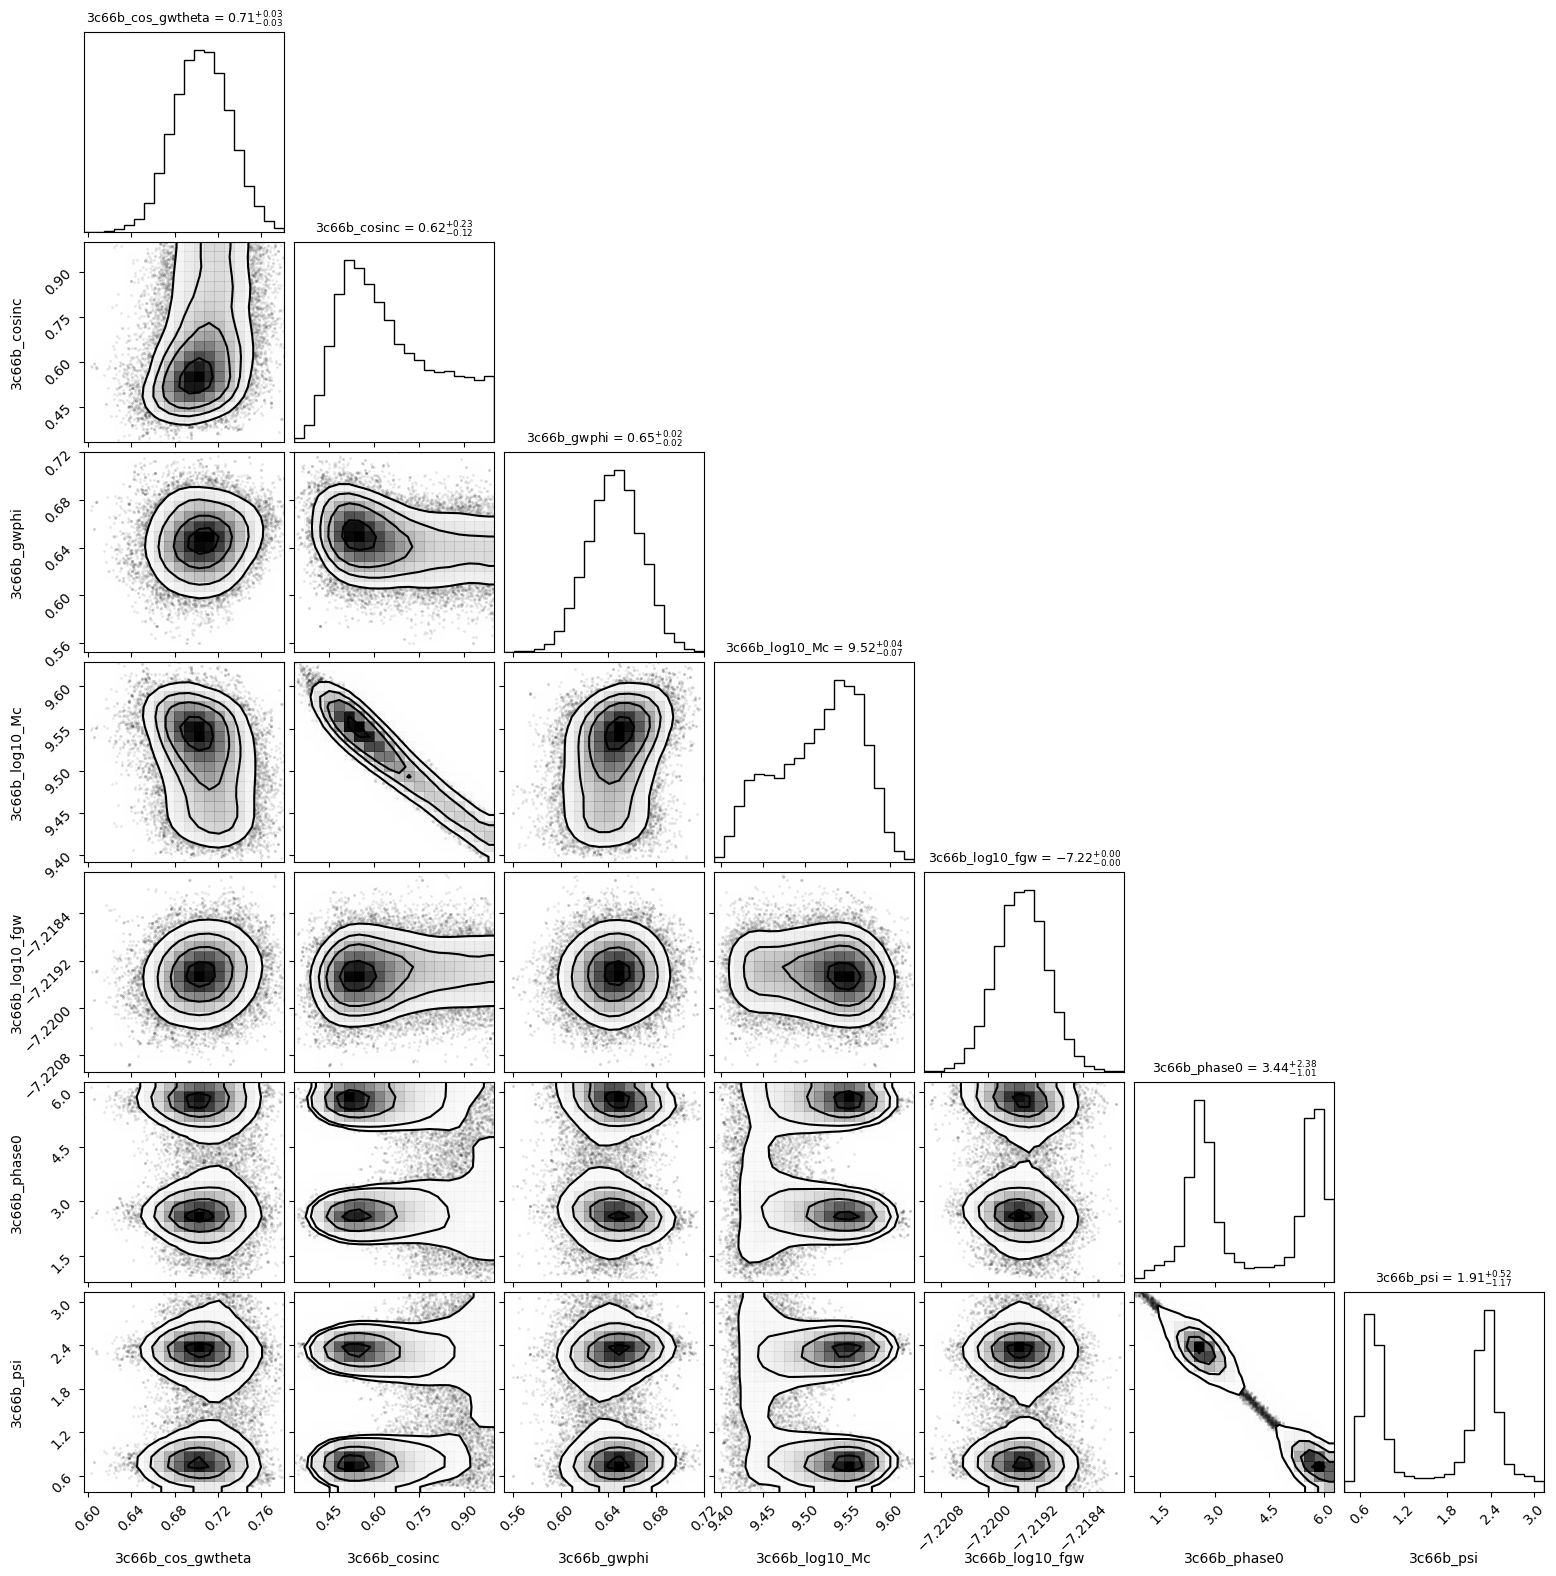

In [21]:
chain = np.loadtxt('./results_targeted_search/chain_1.txt')
pars = sorted(pta.param_names)

# Find indices of global CW parameters (not per-pulsar)
cw_par_names = [p for p in pars if p.startswith('3c66b_')]
cw_par_idx = [pars.index(p) for p in cw_par_names]

print("CW parameters and their indices:")
for name, idx in zip(cw_par_names, cw_par_idx):
    print(f"  [{idx}] {name}")

# Plot corner
burn = int(0.25 * chain.shape[0])
cw_samples = chain[burn:, cw_par_idx]

fig = corner.corner(cw_samples,
                    labels=cw_par_names,
                    smooth=True,
                    show_titles=True,
                    title_kwargs={'fontsize': 9})
plt.show()


Okay. 
# Time to Diagnose the search.
We will use la-forge for this.



In [22]:
#import la_forge.core as co
#import la_forge.diagnostics as dg
np.savetxt('./results_targeted_search/pars.txt', pars, fmt='%s')
chaindir = './results_targeted_search/'
c0 = co.Core(chaindir, burn=0.25, label='cw_hunt')
print('Number of parameters: \t',len(c0.params))
print('Chain shape: \t\t',c0.chain.shape)
print('Burn: \t\t\t' , c0.burn)

Number of parameters: 	 31
Chain shape: 		 (34601, 31)
Burn: 			 8650


/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/la_forge/core.py:179: UserWarning: loadtxt: input contained no data: "./results_targeted_search/covarianceJumpProposalAM_jump.txt"
/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/la_forge/core.py:179: UserWarning: loadtxt: input contained no data: "./results_targeted_search/covarianceJumpProposalSCAM_jump.txt"
/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/la_forge/core.py:179: UserWarning: loadtxt: input contained no data: "./results_targeted_search/DEJump_jump.txt"


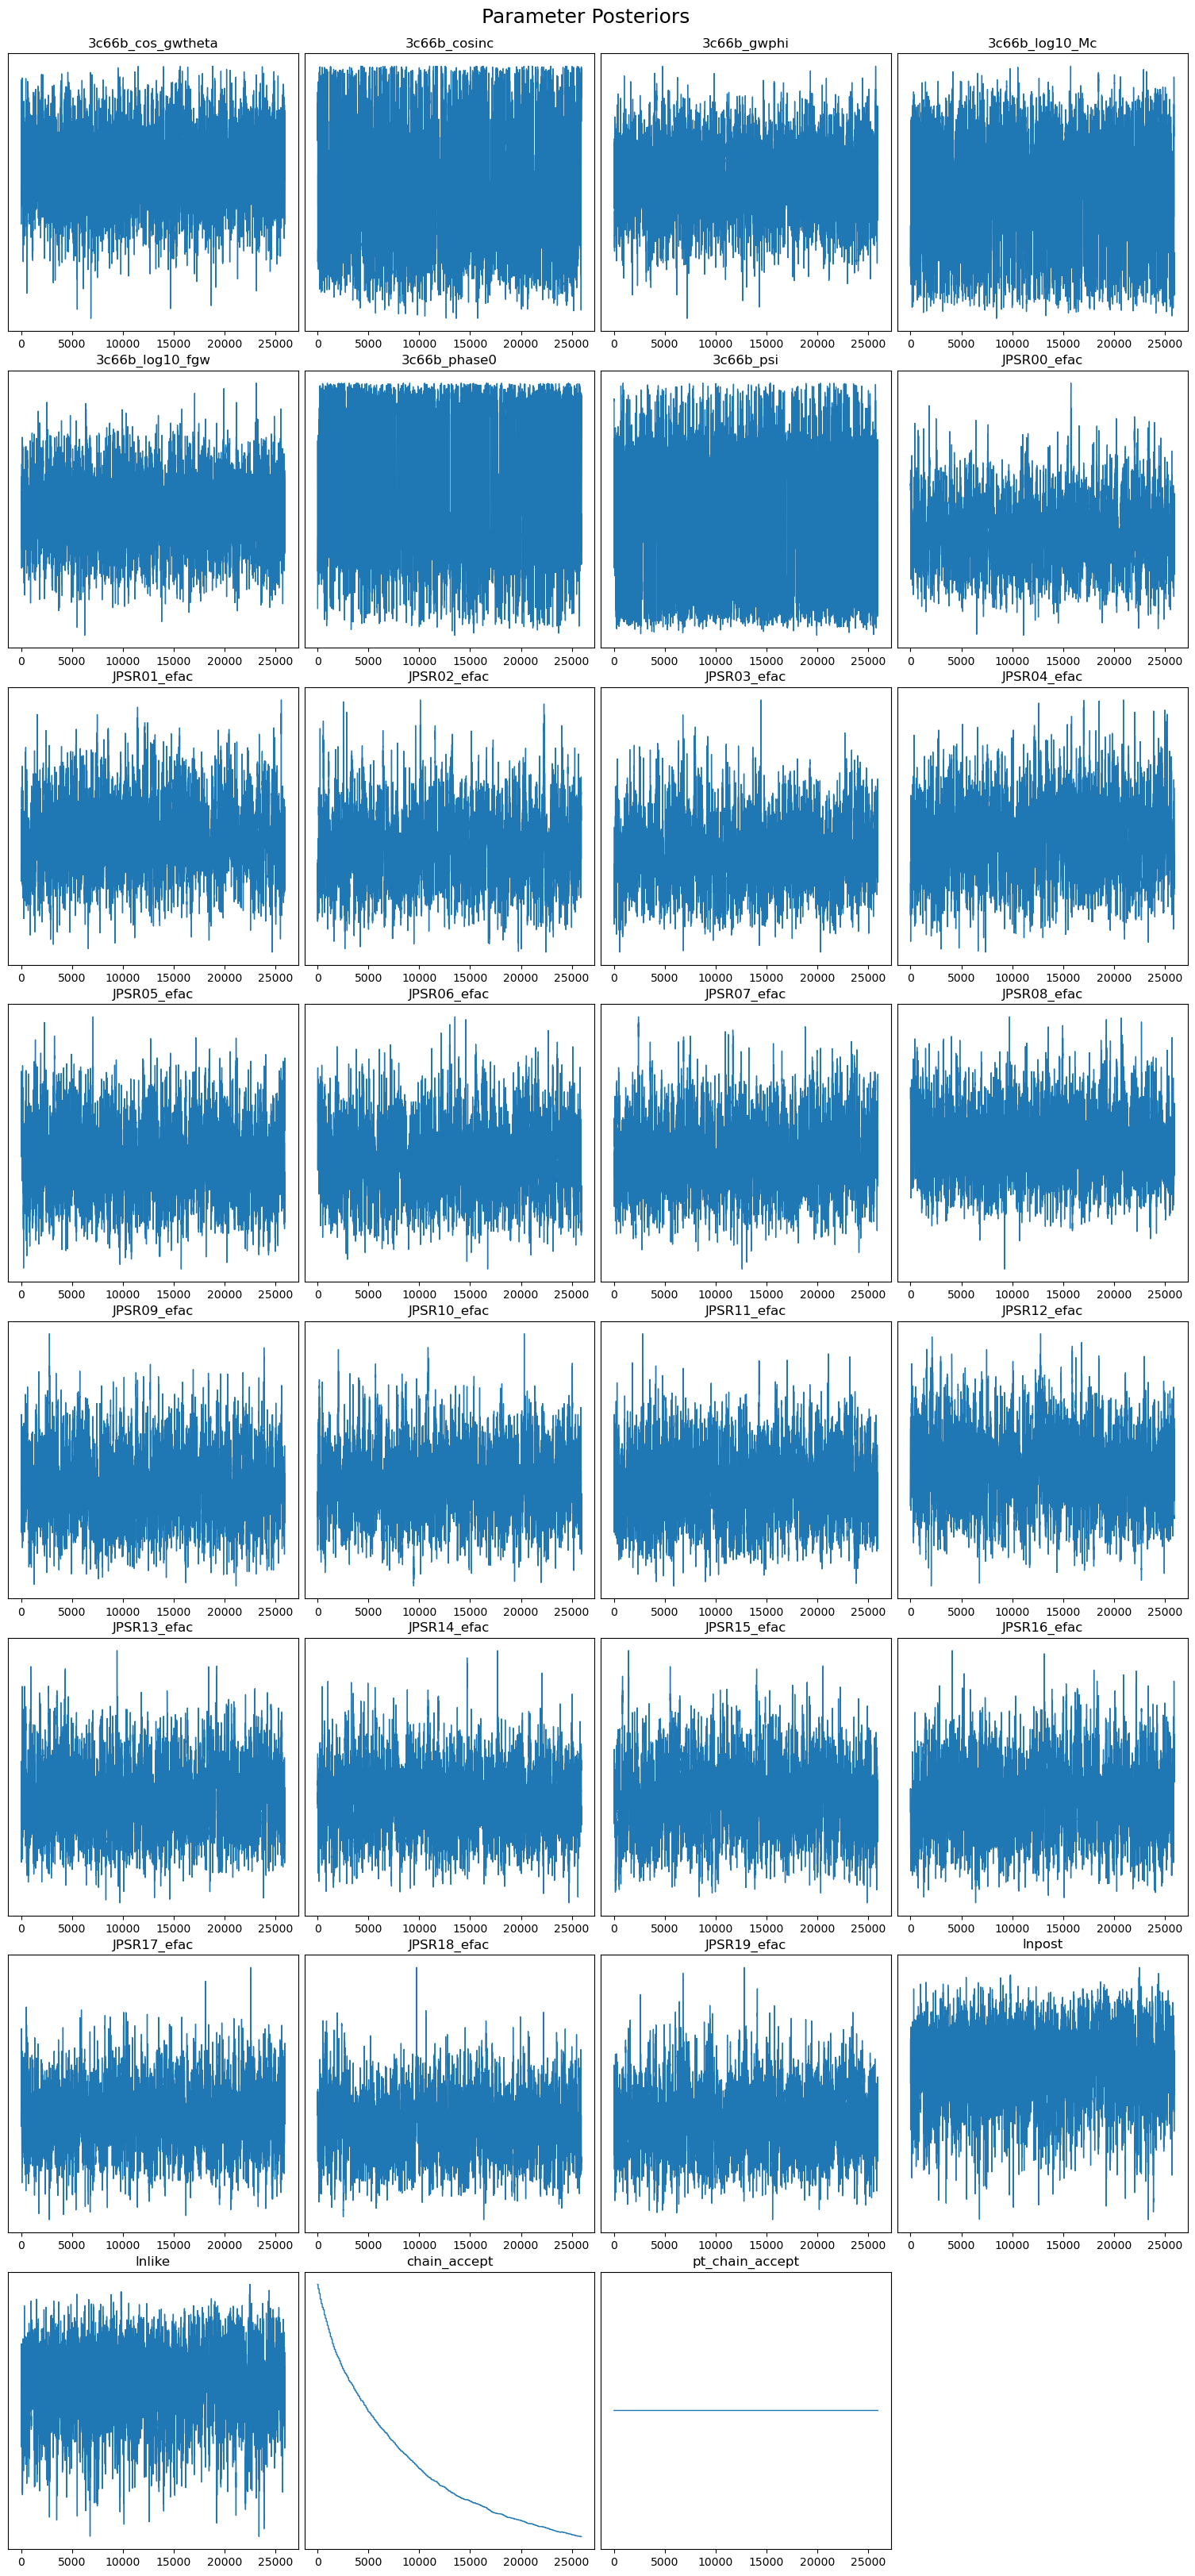

In [23]:
#check trace pltos
dg.plot_chains(c0,
               hist=False,
               pars=c0.params[:],
               ncols=4)

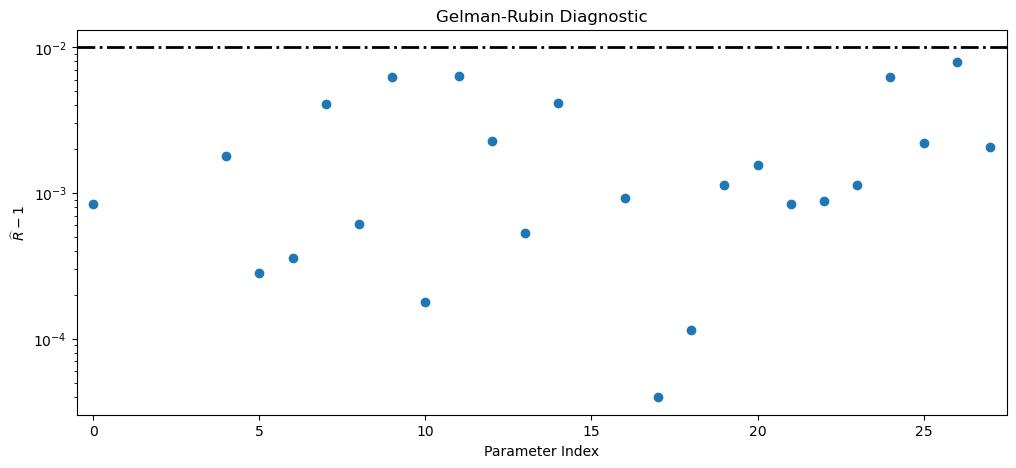

In [24]:
# Look at the Gelman Rubin diagnostic
dg.plot_grubin(c0)


# Run longer! 
Use N = 1_000_000

Remember to set Resume=True

Do the sampling later when you have time, and let it run.

Check diagnostics and CW posteriors.

In [25]:
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov,
                 groups=groups,
                 outDir='./results_targeted_search/',
                 resume=True)

N = 1000_000 
x0 = np.hstack([p.sample() for p in pta.params])
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Resuming run from chain file ./results_targeted_search//chain_1.txt
Resuming with 34601 samples from file representing 346001 original samples
Adding DE jump with weight 50


/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log


Finished 100.00 percent (100.00 percent of new work) in 3752.074861 s Acceptance rate = 0.360234
Run Complete


CW parameters and their indices:
  [0] 3c66b_cos_gwtheta
  [1] 3c66b_cosinc
  [2] 3c66b_gwphi
  [3] 3c66b_log10_Mc
  [4] 3c66b_log10_fgw
  [5] 3c66b_phase0
  [6] 3c66b_psi


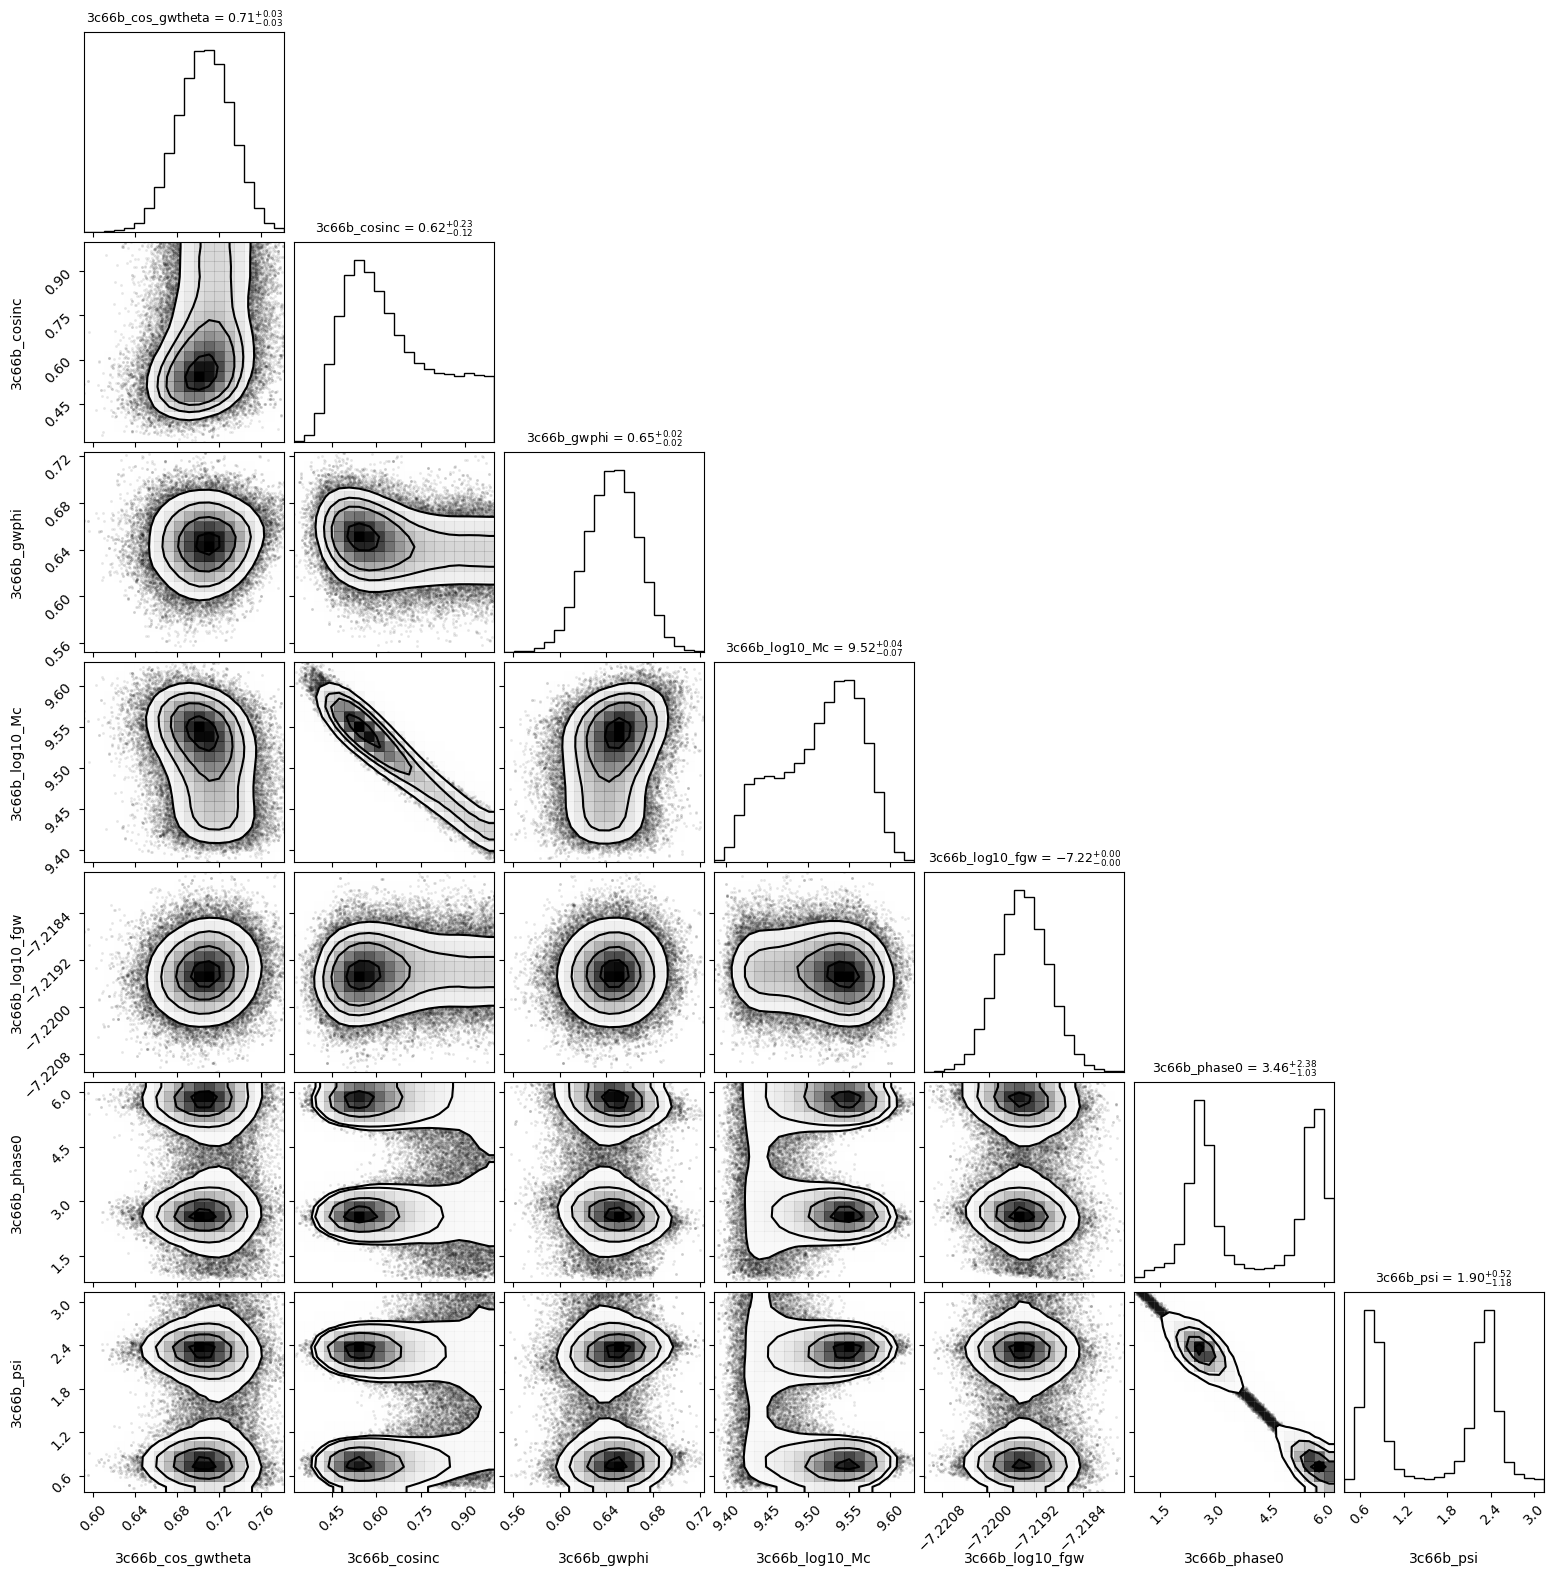

In [26]:
chain = np.loadtxt('./results_targeted_search/chain_1.txt')

# Find indices of global CW parameters (not per-pulsar)
cw_par_names = [p for p in pars if p.startswith('3c66b_')]
cw_par_idx = [pars.index(p) for p in cw_par_names]

print("CW parameters and their indices:")
for name, idx in zip(cw_par_names, cw_par_idx):
    print(f"  [{idx}] {name}")

# Plot corner
burn = int(0.25 * chain.shape[0])
cw_samples = chain[burn:, cw_par_idx]

fig = corner.corner(cw_samples,
                    labels=cw_par_names,
                    smooth=True,
                    show_titles=True,
                    title_kwargs={'fontsize': 9})
plt.show()



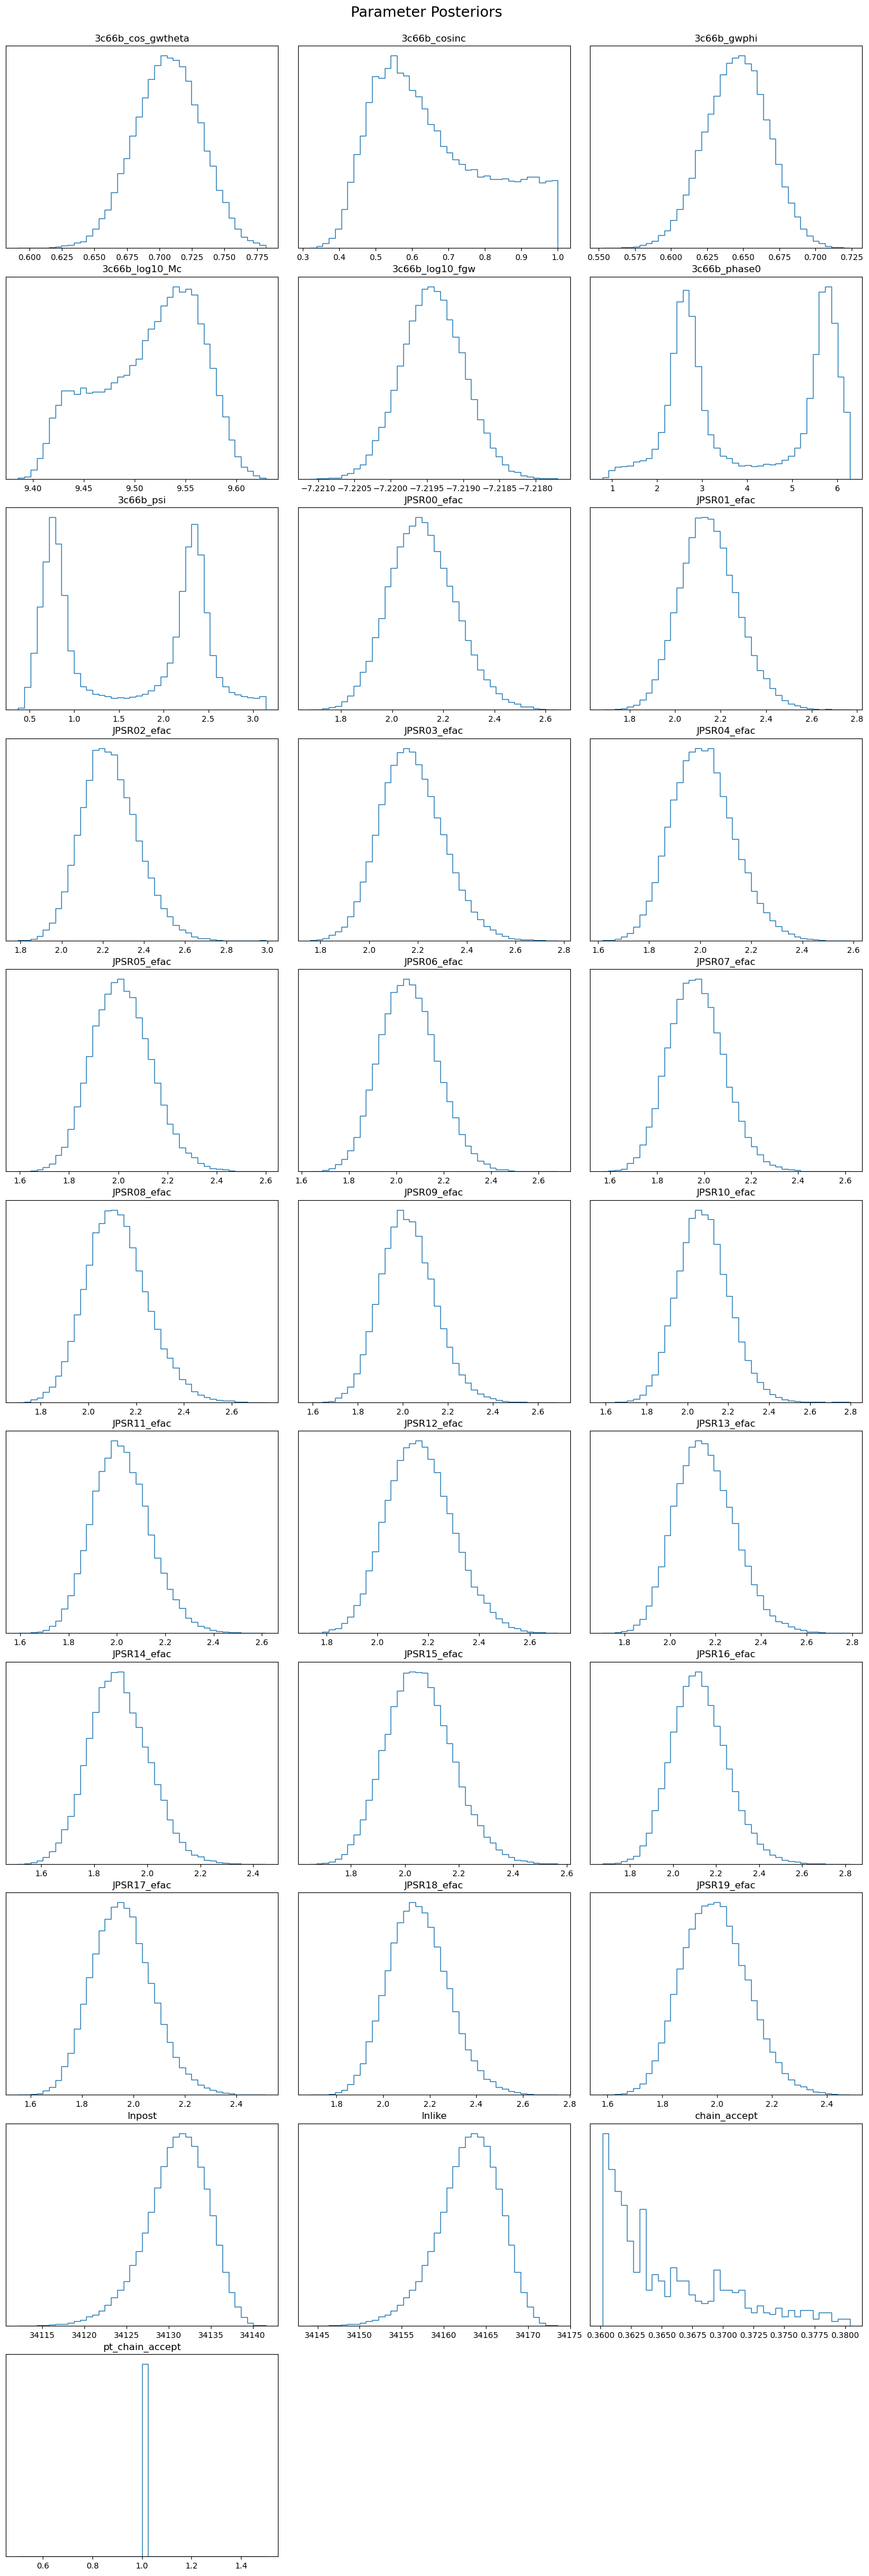

In [27]:
c1 = co.Core(chaindir, burn=0.25, label='cw_hunt_targeted')
dg.plot_chains(c1,hist=True)

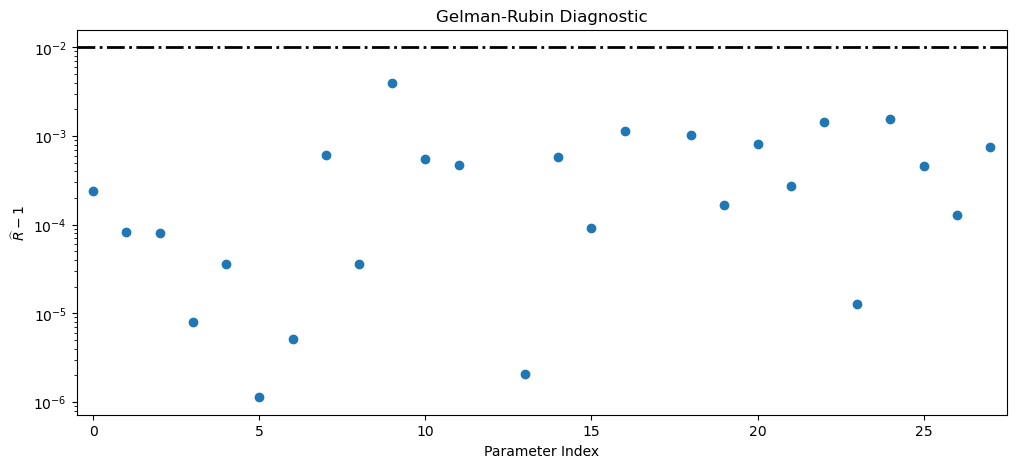

In [28]:
dg.plot_grubin(c1)